# Handling Missing Data

## Introduction

In this project, I explore how to handle missing data in a retail dataset. We will use Python's `pandas` library for data manipulation, `seaborn` for visualization, and `scipy` for outlier detection. The goal of this project is to clean the data, handle missing values using various techniques, and prepare it for further analysis or modeling.

### Dataset: `train.csv`
This dataset contains product information, including categories and sales. Some columns have missing data, and we'll use various strategies to handle it.

## Step 1: Load Required Libraries

We'll start by loading the necessary libraries: 
- `pandas` for data manipulation,
- `numpy` for numerical operations,
- `seaborn` and `matplotlib` for data visualization,
- `scipy` for statistical analysis.

### Loading the Data
Next, we'll load the dataset into a pandas DataFrame to inspect its structure.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


In [3]:
df = pd.read_csv('train.csv')
print("Initial DataFrame:")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

In [3]:
df.shape

(550068, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB


In [5]:
df.dtypes

User_ID                         int64
Product_ID                     object
Gender                         object
Age                            object
Occupation                      int64
City_Category                  object
Stay_In_Current_City_Years     object
Marital_Status                  int64
Product_Category_1              int64
Product_Category_2            float64
Product_Category_3            float64
Purchase                        int64
dtype: object

## Step 2: Handle Missing Data

### 2.1 Visualizing Missing Data

Before cleaning the data, it's important to understand where the missing values are. We will visualize the missing data using a heatmap.


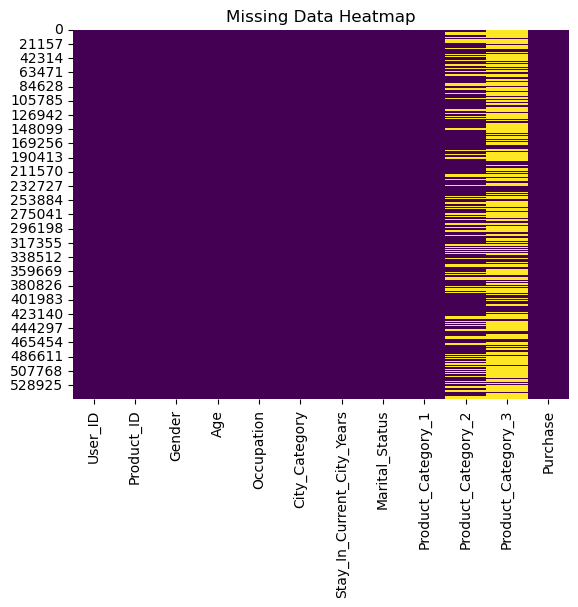

Missing values in each column:
User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64


In [6]:
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

df_missing_sum = df.isnull().sum()
print("Missing values in each column:")
print(df_missing_sum)


### 2.2 Outlier Detection

Outliers can affect the filling of missing data, especially when using methods like mean or median. Here, we'll use the Z-score to detect and handle outliers in `Product_Category_2`.


In [7]:
# Outlier Detection
df_non_nan = df[['Product_Category_2']].dropna()
z_scores = stats.zscore(df_non_nan['Product_Category_2']) #values relation to the mean
abs_z_scores = np.abs(z_scores) #Absolute value
filtered_entries = abs_z_scores < 3
non_nan_indices = df_non_nan.index
filter_series = pd.Series(False, index=df.index)
filter_series.loc[non_nan_indices] = filtered_entries

In [8]:
df_cleaned = df[filter_series]
print("DataFrame shape after outlier removal:")
print(df_cleaned.shape)

DataFrame shape after outlier removal:
(376430, 12)


### 2.3 Dropping Missing Data

In some cases, dropping rows or columns with missing values is a viable option if the percentage of missing data is low. We'll try dropping rows and columns with missing values to see how much data is lost.


In [9]:
df_clean = df.dropna()
print("DataFrame shape after dropping rows with missing values:")
print(df_clean.shape)

DataFrame shape after dropping rows with missing values:
(166821, 12)


In [10]:
df_clean_column = df.dropna(axis=1)
print("DataFrame shape after dropping columns with missing values:")
print(df_clean_column.shape)

DataFrame shape after dropping columns with missing values:
(550068, 10)


In [11]:
print("Missing values in columns after dropping columns:")
print(df_clean_column.isnull().sum())

Missing values in columns after dropping columns:
User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Purchase                      0
dtype: int64


### 2.4 Filling Missing Data

If dropping values isn't ideal (e.g., losing too much data), we can fill the missing values using several strategies:
- **Filling with zero**
- **Filling with median**
- **Filling with mean**
- **Filling with mode**

We'll demonstrate each technique for columns with missing data.


In [12]:
df_filled = df.fillna(0)
print("Missing values after filling with zero:")
print(df_filled.isnull().sum())

Missing values after filling with zero:
User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
Purchase                      0
dtype: int64


### Median

In [13]:
df["Product_Category_2"] = df["Product_Category_2"].fillna(df["Product_Category_2"].median())
df["Product_Category_2"]

0          9.0
1          6.0
2          9.0
3         14.0
4          9.0
          ... 
550063     9.0
550064     9.0
550065     9.0
550066     9.0
550067     9.0
Name: Product_Category_2, Length: 550068, dtype: float64

In [14]:
df["Product_Category_3"] = df["Product_Category_3"].fillna(df["Product_Category_3"].median())
df["Product_Category_3"]

0         14.0
1         14.0
2         14.0
3         14.0
4         14.0
          ... 
550063    14.0
550064    14.0
550065    14.0
550066    14.0
550067    14.0
Name: Product_Category_3, Length: 550068, dtype: float64

### Mean

In [15]:
df["Product_Category_2"] = df["Product_Category_2"].fillna(df["Product_Category_2"].mean())
df["Product_Category_2"]

0          9.0
1          6.0
2          9.0
3         14.0
4          9.0
          ... 
550063     9.0
550064     9.0
550065     9.0
550066     9.0
550067     9.0
Name: Product_Category_2, Length: 550068, dtype: float64

In [16]:
df["Product_Category_3"] = df["Product_Category_3"].fillna(df["Product_Category_3"].mean())
df["Product_Category_3"]

0         14.0
1         14.0
2         14.0
3         14.0
4         14.0
          ... 
550063    14.0
550064    14.0
550065    14.0
550066    14.0
550067    14.0
Name: Product_Category_3, Length: 550068, dtype: float64

### Mode

In [17]:
df["Product_Category_2"] = df["Product_Category_2"].fillna(df["Product_Category_2"].mode()[0])
df["Product_Category_2"]

0          9.0
1          6.0
2          9.0
3         14.0
4          9.0
          ... 
550063     9.0
550064     9.0
550065     9.0
550066     9.0
550067     9.0
Name: Product_Category_2, Length: 550068, dtype: float64

In [18]:
df["Product_Category_3"] = df["Product_Category_3"].fillna(df["Product_Category_3"].mode()[0])
df["Product_Category_3"]

0         14.0
1         14.0
2         14.0
3         14.0
4         14.0
          ... 
550063    14.0
550064    14.0
550065    14.0
550066    14.0
550067    14.0
Name: Product_Category_3, Length: 550068, dtype: float64

In [19]:
df.interpolate(method='linear', inplace=True)
print("DataFrame after interpolation:")
df.head()

DataFrame after interpolation:


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,9.0,14.0,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,9.0,14.0,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,14.0,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,9.0,14.0,7969


In [20]:
#Display cleaned DataFrame shapes
print("Original DataFrame shape:", df.shape)
print("Cleaned DataFrame shape:", df_clean.shape)
print("Cleaned DataFrame with outliers removed shape:", df_cleaned.shape)

Original DataFrame shape: (550068, 12)
Cleaned DataFrame shape: (166821, 12)
Cleaned DataFrame with outliers removed shape: (376430, 12)


## Conclusion

In this project, we explored various strategies for handling missing data in a retail dataset. We visualized the missing values, detected outliers, and used techniques such as dropping, filling with statistical methods, and interpolation to handle the missing data. 

Next steps could include:
- Further outlier analysis,
- Feature engineering,
- Building predictive models using this cleaned dataset.



### Summary:
- **Step 1**: Load libraries and dataset.
- **Step 2**: Handle missing data through visualization, outlier detection, dropping, filling, and interpolation.
- **Conclusion**: Summarize findings and suggest next steps. 